In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

from sklearn.compose import ColumnTransformer

In [3]:
inter_dir = '../../02_INTERMEDIATE'
merged_filepath = f'{inter_dir}/merged_acre_ecoplanet_parameters.gpkg'
if os.path.exists(merged_filepath):
    df = gpd.read_file(merged_filepath)
else:
    print('Invalid source path')

In [4]:
len(df)

217

#### Preparing the dataset for modelling and validation

In [5]:
df.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2', 'geometry'],
      dtype='str')

In [6]:
psps = df['psp'].unique()
for psp in psps:
    df_psp = df[df['psp']==psp]
    print(f'psp: {psp}, dates: {df_psp['date_of_collection'].unique()}')

psp: 1a-APM-01, dates: <StringArray>
['4/24/2025', '4/2/2026']
Length: 2, dtype: str
psp: 1a-APM-02, dates: <StringArray>
['4/25/2025', '5/3/2026']
Length: 2, dtype: str
psp: 1a-APM-07, dates: <StringArray>
['5/15/2025', '2/20/2026']
Length: 2, dtype: str
psp: 1a-APM-08, dates: <StringArray>
['5/15/2025', '2/24/2026']
Length: 2, dtype: str
psp: 1a-APM-13, dates: <StringArray>
['6/18/2025', '3/17/2026']
Length: 2, dtype: str
psp: 1a-GB-03, dates: <StringArray>
['5/20/2025', '6/3/2026']
Length: 2, dtype: str
psp: 1a-GB-05, dates: <StringArray>
['6/18/2025', '3/13/2026', '6/24/2026']
Length: 3, dtype: str


In [7]:
# ---------------------------------------
# MODELLING DATA
# ---------------------------------------

model_df = df.copy()

# Keep 2026 only
model_df = model_df[model_df["year"] == 2026].copy()
model_df = model_df.loc[model_df['total_agb'] != 0]
#Target plot and date to remove
target_plot = '1a-GB-05'
target_date = '3/13/2026'

# Filter out the specific row using boolean indexing
model_df = model_df[~((model_df['psp'] == target_plot) & (df['date_of_collection'] == target_date))]
model_df['adjusted_volume'] = model_df['canopy_volume_m3'] * model_df['gap_fraction']

# Required columns
model_df = model_df[
    [
        "psp",
        "clump_id",
        "total_agb",
        "total_culms",
        "canopy_volume_m3",
        'adjusted_volume',
        'canopy_area',
        'hmean',
        'hmedian',
        'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2'
    ]
].dropna()

print("Number of observations:", len(model_df))
print("Number of PSPs:", model_df["psp"].nunique())
print("PSPs:", model_df["psp"].unique())

Number of observations: 77
Number of PSPs: 7
PSPs: <StringArray>
['1a-APM-01', '1a-APM-02', '1a-APM-07', '1a-APM-08', '1a-APM-13',  '1a-GB-03',
  '1a-GB-05']
Length: 7, dtype: str


/home/gacho/projects/acre_insights/ecoplanet_bamboo/04_SCRIPTS/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


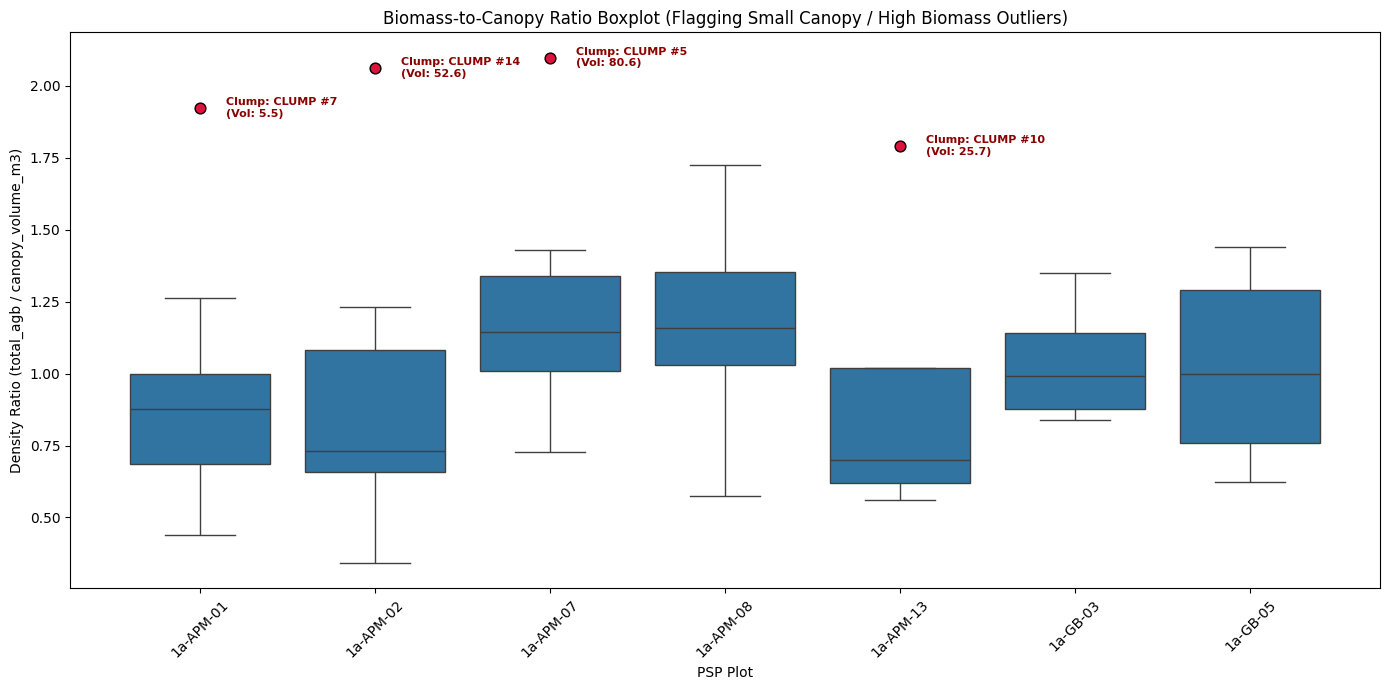

In [8]:
# Compute the ratio on the main dataframe directly
model_df['agb_to_volume_ratio'] = model_df['total_agb'] / (model_df['canopy_volume_m3'] + 1e-5)

# Calculate Q1, Q3, and IQR dynamically per plot using transform
q1 = model_df.groupby('psp')['agb_to_volume_ratio'].transform('quantile', 0.25)
q3 = model_df.groupby('psp')['agb_to_volume_ratio'].transform('quantile', 0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# Flag rows where the ratio breaks the upper threshold
model_df['is_outlier'] = model_df['agb_to_volume_ratio'] > upper_bound

# Isolate outliers for tracking/plotting
outliers = model_df[model_df['is_outlier']]
# --- 2. Boxplot of the Ratio per PSP with clump_id labels ---

plt.figure(figsize=(14, 7))
# psp is guaranteed to be a column now
ax = sns.boxplot(x='psp', y='agb_to_volume_ratio', data=model_df, showfliers=False)

# Get the ordered list of categories directly from the seaborn axis object
psp_order = [label.get_text() for label in ax.get_xticklabels()]

# Iterate and overlay the specific clump_id text labels
for psp_val, group in outliers.groupby('psp'):
    try:
        # Map the psp name to its matching X integer coordinate on the chart
        x_coord = psp_order.index(str(psp_val))
        
        for idx, row in group.iterrows():
            ratio_val = row['agb_to_volume_ratio']
            cid = row['clump_id']
            
            # Plot a clean marker for the outlier
            plt.scatter(x_coord, ratio_val, color='crimson', zorder=5, s=60, edgecolors='black')
            
            # Label with clump_id
            plt.text(x_coord + 0.15, ratio_val, f"Clump: {cid}\n(Vol: {row['canopy_volume_m3']:.1f})", 
                     verticalalignment='center', color='darkred', fontsize=8, weight='bold')
    except ValueError:
        continue

plt.title('Biomass-to-Canopy Ratio Boxplot (Flagging Small Canopy / High Biomass Outliers)')
plt.ylabel('Density Ratio (total_agb / canopy_volume_m3)')
plt.xlabel('PSP Plot')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- 3. Safely drop the outliers ---

model_df_clean = model_df[~model_df['is_outlier']].drop(columns=['agb_to_volume_ratio', 'is_outlier'])
# Clean up temporary columns from original dataframe as well
model_df = model_df_clean.copy()


In [9]:
model_df_clean.describe()

,total_agb,total_culms,canopy_volume_m3,adjusted_volume,canopy_area,hmean,hmedian,breast_height_points,breast_height_valid_points,breast_height_filtered_points,breast_height_cleaning_distance,breast_height_area,breast_height_perimeter_m,breast_height_diameter,bh_outside_area_m2
count,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000
mean,141.087397,36.493151,141.619726,23.657240,23.847123,4.351781,4.448082,2199.000000,26496.698630,1357.301370,0.108767,14.027808,13.558356,3.903425,9.819452
std,111.409054,20.312232,105.194847,25.150138,14.791181,1.146903,1.208158,1407.653347,16440.053793,833.066369,0.030684,9.988691,5.716227,1.631534,9.069771
min,1.310000,3.000000,1.870000,0.261600,0.890000,1.490000,1.680000,153.000000,986.000000,153.000000,0.070000,0.520000,2.830000,0.810000,0.130000
25%,41.220000,19.000000,51.510000,3.818000,11.170000,3.510000,3.580000,1277.000000,12422.000000,792.000000,0.090000,5.730000,9.510000,2.700000,2.930000
50%,130.870000,37.000000,123.580000,13.506000,23.260000,4.500000,4.530000,1924.000000,25808.000000,1234.000000,0.090000,13.110000,13.960000,4.080000,8.610000
75%,215.700000,50.000000,223.510000,37.872000,34.000000,5.080000,5.410000,2898.000000,37785.000000,1686.000000,0.130000,20.670000,17.280000,5.130000,13.120000
max,362.770000,82.000000,431.760000,120.892800,59.840000,6.800000,7.390000,6763.000000,66516.000000,4050.000000,0.180000,47.630000,28.520000,7.790000,51.350000


In [10]:
print(
    model_df["psp"]
    .value_counts()
    .sort_index()
)

psp
1a-APM-01    12
1a-APM-02    11
1a-APM-07     9
1a-APM-08    13
1a-APM-13     3
1a-GB-03     11
1a-GB-05     14
Name: count, dtype: int64


##### Define site specific K fold

In [11]:
groups = model_df["psp"]

gkf = GroupKFold(n_splits=6)

##### Create one common evaluation function

In [12]:
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    residuals = y_true - y_pred

    sse = np.sum(residuals ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - (sse / sst)

    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals ** 2))

    # Relative RMSE expressed as a percentage of mean observed biomass
    rrmse = 100 * rmse / np.mean(y_true)

    # Mean bias error
    mbe = np.mean(residuals)

    # Mean percentage bias
    # Exclude zero targets to avoid division by zero
    nonzero = y_true != 0

    bias = 100 * np.mean(
        residuals[nonzero] / y_true[nonzero]
    )

    mape = 100 * np.mean(
        np.abs(residuals[nonzero]) / y_true[nonzero]
    )

    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "rRMSE_percent": rrmse,
        "MBE": mbe,
        "Bias_percent": bias,
        "MAPE_percent": mape
    }

#### M0: Null model
* **Feature:** This model has no features. It predicts the mean biomass for each clump, therefore creating a baseline for which each model is judged.

In [13]:
# ---------------------------------------
# M0: NULL MODEL
# ---------------------------------------

m0_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]
    
    # Mean biomass from training PSPs only
    train_mean = train["total_agb"].mean()

    y_true = test["total_agb"]
    y_pred = np.full(
        len(test),
        train_mean
    )

    fold_results = test[
        ["psp", "clump_id", "total_agb"]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M0_null"

    m0_predictions.append(fold_results)


m0_predictions = pd.concat(
    m0_predictions,
    ignore_index=True
)

##### Overall out of fold metrics

In [14]:
m0_metrics = calculate_metrics(
    m0_predictions["total_agb"],
    m0_predictions["prediction"]
)

print("M0: Null Model")
print("-" * 40)

for metric, value in m0_metrics.items():
    print(f"{metric}: {value:.4f}")

M0: Null Model
----------------------------------------
R2: -0.1518
MAE: 100.5552
RMSE: 118.7433
rRMSE_percent: 84.1630
MBE: 0.4681
Bias_percent: -722.2487
MAPE_percent: 758.7045


##### Per psp M0

In [15]:
m0_by_psp = []

for psp, group in m0_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m0_by_psp.append(metrics)


m0_by_psp = pd.DataFrame(m0_by_psp)

m0_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
]

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,-1.590135,94.925970,105.437579,146.330994
1,1a-APM-02,-1.136342,80.632962,94.548459,114.573892
2,1a-APM-07,-0.353891,68.313060,80.718135,75.847859
3,1a-APM-08,-0.074690,93.129538,106.089414,89.830156
4,1a-APM-13,-0.198339,90.173060,90.551558,81.688370
5,1a-GB-03,-1.092241,129.038856,149.708547,64.264631
6,1a-GB-05,-0.853778,128.500569,151.532355,67.587380


#### Predicting the total culms for use in prediction

In [16]:
model_df.columns

Index(['psp', 'clump_id', 'total_agb', 'total_culms', 'canopy_volume_m3',
       'adjusted_volume', 'canopy_area', 'hmean', 'hmedian',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2'],
      dtype='str')

In [17]:
from sklearn.model_selection import KFold

# 1. Initialize standard KFold instead of GroupKFold
# Shuffle=True ensures random distribution of rows across folds
kf = KFold(n_splits=6, shuffle=True, random_state=42) 

m3_predictions_culms = []

# 2. Remove the groups argument from the split method
for train_idx, test_idx in kf.split(model_df):
    culms_df = model_df.copy()
    culms_df = culms_df.loc[culms_df['total_culms'] != 0]
    train = culms_df.iloc[train_idx] 
    test = culms_df.iloc[test_idx]

    # -----------------------------
    # Training data
    # -----------------------------
    X_train = train[
        ['hmean', 'breast_height_perimeter_m', 'breast_height_valid_points']
    ]
    y_train = train["total_culms"]

    # -----------------------------
    # Test data
    # -----------------------------
    X_test = test[
        ['hmean', 'breast_height_perimeter_m', 'breast_height_valid_points']
    ]
    y_test = test["total_culms"]

    # -----------------------------
    # Create polynomial features
    # -----------------------------
    poly_transformer = ColumnTransformer(
        transformers=[
            ('volume_poly', PolynomialFeatures(degree=2, include_bias=False), ['breast_height_perimeter_m'])
        ],
        remainder='passthrough' 
    )

    X_train_poly = poly_transformer.fit_transform(X_train)
    X_test_poly = poly_transformer.transform(X_test)

    # -----------------------------
    # Linear regression on polynomial features
    # -----------------------------
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # -----------------------------
    # Predict held-out PSP
    # -----------------------------
    y_pred = model.predict(X_test_poly)

    # -----------------------------
    # Store predictions
    # -----------------------------
    fold_results = test[
        [
            "psp", "clump_id", "total_agb", 'total_culms',
            'breast_height_valid_points', 'breast_height_points',
            'breast_height_perimeter_m', 'breast_height_diameter',
            'breast_height_area', 'bh_outside_area_m2', 'hmean',
            'canopy_volume_m3', 'canopy_area'
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M3_polynomial_volume"

    m3_predictions_culms.append(fold_results)

m3_predictions_culms = pd.concat(
    m3_predictions_culms,
    ignore_index=True
)
m3_predictions_culms['prediction'] = round(m3_predictions_culms['prediction'])


In [18]:
m3_culms_metrics = calculate_metrics(
    m3_predictions_culms['total_culms'],
    m3_predictions_culms['prediction']
)
print("Culms prediction")
print('-'*41)
for metric, value in m3_culms_metrics.items():
    print(f'{metric}:{value:.4f}')

Culms prediction
-----------------------------------------
R2:0.6447
MAE:9.2740
RMSE:12.0245
rRMSE_percent:32.9501
MBE:0.0959
Bias_percent:-14.8805
MAPE_percent:37.1841


#### M1: Simple linear model
* `AGB=β0​+β1​Volume` Intentionally simple, with one predictor(canopy volume)

In [19]:
model_df.columns

Index(['psp', 'clump_id', 'total_agb', 'total_culms', 'canopy_volume_m3',
       'adjusted_volume', 'canopy_area', 'hmean', 'hmedian',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2'],
      dtype='str')

In [20]:
# ---------------------------------------
# M1: LINEAR MODEL
# AGB ~ canopy_volume_m3
# ---------------------------------------

m1_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    X_train = train[
        ['canopy_volume_m3'
               ]
    ]

    y_train = train[
        "total_agb"
    ]

    X_test = test[
        ['canopy_volume_m3'
               ]
    ]

    y_test = test[
        "total_agb"
    ]

    model = LinearRegression()

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    fold_results = test[
        ["psp", "clump_id", "total_agb"]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M1_linear"

    m1_predictions.append(
        fold_results
    )


m1_predictions = pd.concat(
    m1_predictions,
    ignore_index=True
)

In [21]:
m1_metrics = calculate_metrics(
    m1_predictions["total_agb"],
    m1_predictions["prediction"]
)

print("M1: Linear Regression")
print("-" * 40)

for metric, value in m1_metrics.items():
    print(f"{metric}: {value:.4f}")

M1: Linear Regression
----------------------------------------
R2: 0.8373
MAE: 31.5663
RMSE: 44.6283
rRMSE_percent: 31.6316
MBE: 1.3717
Bias_percent: -19.6203
MAPE_percent: 38.0610


In [22]:
fold_info = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(model_df, groups=model_df["psp"])
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    fold_info.append({
        "fold": fold,
        "test_psp": test["psp"].unique().tolist(),
        "n_train": len(train),
        "n_test": len(test),

        "train_agb_min": train["total_agb"].min(),
        "train_agb_max": train["total_agb"].max(),
        "train_agb_mean": train["total_agb"].mean(),

        "test_agb_min": test["total_agb"].min(),
        "test_agb_max": test["total_agb"].max(),
        "test_agb_mean": test["total_agb"].mean(),

        "test_agb_std": test["total_agb"].std()
    })

fold_info = pd.DataFrame(fold_info)

fold_info

,fold,test_psp,n_train,n_test,train_agb_min,train_agb_max,train_agb_mean,test_agb_min,test_agb_max,test_agb_mean,test_agb_std
0,0,[1a-GB-05],59,14,1.31,362.77,121.365254,21.01,359.82,224.202143,115.496522
1,1,[1a-APM-08],60,13,1.31,362.77,146.068000,1.43,292.78,118.100000,106.515184
2,2,[1a-APM-01],61,12,1.31,362.77,154.667705,7.63,211.12,72.054167,68.427158
3,3,[1a-GB-03],62,11,1.31,359.82,124.788065,10.00,362.77,232.956364,108.551808
4,4,[1a-APM-02],62,11,1.43,362.77,151.478065,1.31,215.70,82.521818,67.844616
5,5,"[1a-APM-07, 1a-APM-13]",61,12,1.31,362.77,147.689180,5.94,240.73,107.528333,76.207126


##### Compare M0 and M1

In [23]:
results_m0_m1 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        }
    ]
)

results_m0_m1

,Model,R2,MAE,RMSE,rRMSE_percent,MBE,Bias_percent,MAPE_percent
0,M0 - Null,-0.151776,100.555210,118.743332,84.162962,0.468115,-722.248670,758.704543
1,M1 - Linear Volume,0.837307,31.566344,44.628252,31.631636,1.371719,-19.620278,38.060972


In [24]:
model_m1_full = LinearRegression()

model_m1_full.fit(
    model_df[["canopy_volume_m3"]],
    model_df["total_agb"]
)

print(
    "Intercept:",
    model_m1_full.intercept_
)

print(
    "Volume coefficient:",
    model_m1_full.coef_[0]
)

Intercept: 2.3383306978105622
Volume coefficient: 0.9797298049822629


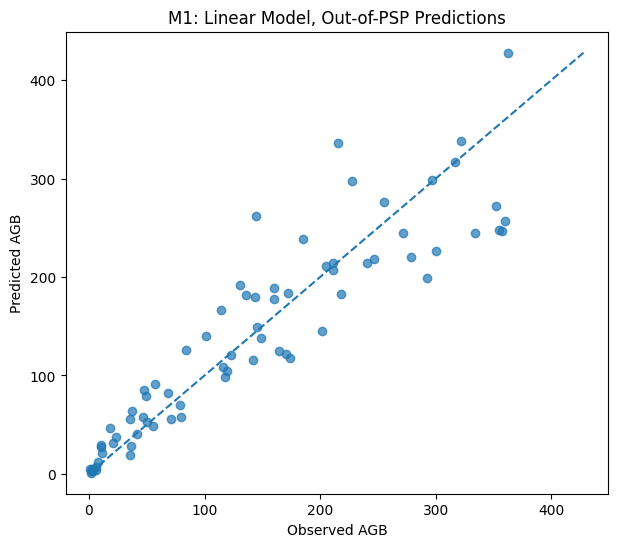

In [25]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m1_predictions["total_agb"],
    m1_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m1_predictions["total_agb"].min(),
    m1_predictions["prediction"].min()
)

max_val = max(
    m1_predictions["total_agb"].max(),
    m1_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title("M1: Linear Model, Out-of-PSP Predictions")

plt.show()

##### Plot the residuals

In [26]:
m1_predictions["residual"] = (
    m1_predictions["total_agb"]
    - m1_predictions["prediction"]
)

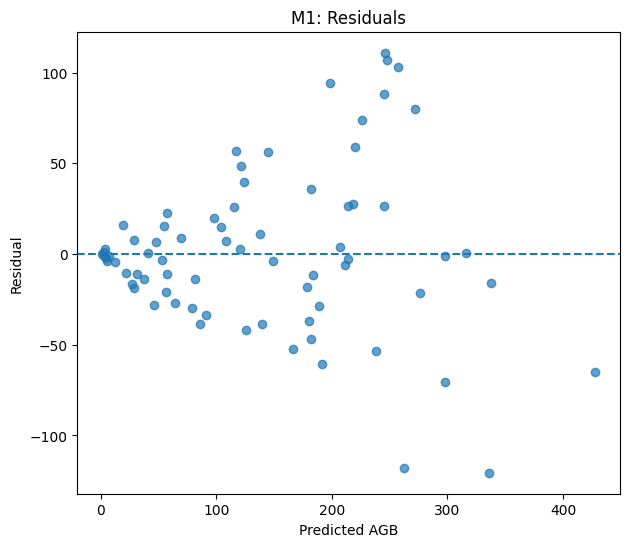

In [27]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m1_predictions["prediction"],
    m1_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")
plt.title("M1: Residuals")

plt.show()

##### Can we spot the site effect by testing on a completely held out psp

In [28]:
m1_by_psp = []

for psp, group in m1_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m1_by_psp.append(metrics)

m1_by_psp = pd.DataFrame(m1_by_psp)

m1_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.654684,23.814567,38.498388,53.429788
1,1a-APM-02,0.526378,27.882147,44.517937,53.946869
2,1a-APM-07,0.887438,19.104429,23.274174,21.869884
3,1a-APM-08,0.875779,23.710698,36.068500,30.540644
4,1a-APM-13,0.632156,47.453191,50.169305,45.258732
5,1a-GB-03,0.828466,32.202383,42.866299,18.400999
6,1a-GB-05,0.675595,52.507140,63.389907,28.273551


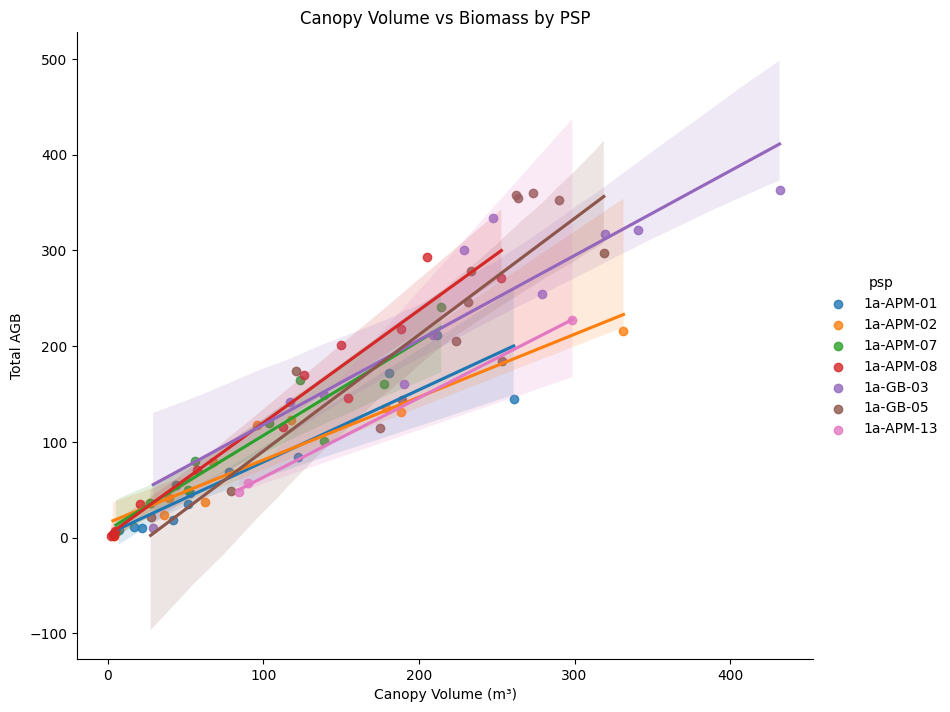

In [29]:
sns.lmplot(
    data=m3_predictions_culms,
    x="canopy_volume_m3",
    y="total_agb",
    height=7,
    hue='psp',
    aspect=1.2
)

plt.xlabel("Canopy Volume (m³)")
plt.ylabel("Total AGB")
plt.title("Canopy Volume vs Biomass by PSP")

plt.show()

In [30]:
m3_predictions_culms.describe()

,total_agb,total_culms,breast_height_valid_points,breast_height_points,breast_height_perimeter_m,breast_height_diameter,breast_height_area,bh_outside_area_m2,hmean,canopy_volume_m3,canopy_area,prediction
count,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000
mean,141.087397,36.493151,26496.698630,2199.000000,13.558356,3.903425,14.027808,9.819452,4.351781,141.619726,23.847123,36.397260
std,111.409054,20.312232,16440.053793,1407.653347,5.716227,1.631534,9.988691,9.069771,1.146903,105.194847,14.791181,17.230254
min,1.310000,3.000000,986.000000,153.000000,2.830000,0.810000,0.520000,0.130000,1.490000,1.870000,0.890000,-2.000000
25%,41.220000,19.000000,12422.000000,1277.000000,9.510000,2.700000,5.730000,2.930000,3.510000,51.510000,11.170000,24.000000
50%,130.870000,37.000000,25808.000000,1924.000000,13.960000,4.080000,13.110000,8.610000,4.500000,123.580000,23.260000,37.000000
75%,215.700000,50.000000,37785.000000,2898.000000,17.280000,5.130000,20.670000,13.120000,5.080000,223.510000,34.000000,51.000000
max,362.770000,82.000000,66516.000000,6763.000000,28.520000,7.790000,47.630000,51.350000,6.800000,431.760000,59.840000,71.000000


#### M2: Area + Height
##### Does area and height add any more significant information than volume

In [31]:
model_df.columns

Index(['psp', 'clump_id', 'total_agb', 'total_culms', 'canopy_volume_m3',
       'adjusted_volume', 'canopy_area', 'hmean', 'hmedian',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2'],
      dtype='str')

In [32]:
# ---------------------------------------
# M2: AREA + MEAN HEIGHT
# ---------------------------------------

m2_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]
   
    X_train = train[
        [
             'hmean', 'canopy_area'
        ]
    ]

    y_train = train["total_agb"]

    X_test = test[
        [
            'hmean', 'canopy_area'
        ]
    ]

    y_test = test["total_agb"]

    # Create model
    model = LinearRegression()

    # Train
    model.fit(
        X_train,
        y_train
    )

    # Predict held-out PSP
    y_pred = model.predict(
        X_test
    )

    # Store out-of-fold predictions
    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M2_area_hmean"

    m2_predictions.append(
        fold_results
    )


m2_predictions = pd.concat(
    m2_predictions,
    ignore_index=True
)

In [33]:
m2_predictions['prediction'] = m2_predictions['prediction'].clip(lower=1)

In [34]:
m2_metrics = calculate_metrics(
    m2_predictions["total_agb"],
    m2_predictions["prediction"]
)

print("M2: Area + Mean Height")
print("-" * 40)

for metric, value in m2_metrics.items():
    print(f"{metric}: {value:.4f}")

M2: Area + Mean Height
----------------------------------------
R2: 0.8311
MAE: 32.2453
RMSE: 45.4783
rRMSE_percent: 32.2341
MBE: -2.2730
Bias_percent: -12.2073
MAPE_percent: 38.4841


##### M0 M1 M2 together

In [35]:
results_m0_m2 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        },
        {
            "Model": "M2 - Area + Mean Height",
            **m2_metrics
        }
    ]
)

results_m0_m2

,Model,R2,MAE,RMSE,rRMSE_percent,MBE,Bias_percent,MAPE_percent
0,M0 - Null,-0.151776,100.555210,118.743332,84.162962,0.468115,-722.248670,758.704543
1,M1 - Linear Volume,0.837307,31.566344,44.628252,31.631636,1.371719,-19.620278,38.060972
2,M2 - Area + Mean Height,0.831050,32.245289,45.478296,32.234131,-2.273033,-12.207301,38.484142


##### M2 performance per psp

In [36]:
m2_by_psp = []

for psp, group in m2_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m2_by_psp.append(metrics)


m2_by_psp = pd.DataFrame(
    m2_by_psp
)

m2_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.545175,32.108437,44.183103,61.319289
1,1a-APM-02,0.553938,31.626025,43.203289,52.353778
2,1a-APM-07,0.905376,17.916716,21.339290,20.051745
3,1a-APM-08,0.952371,16.095978,22.334042,18.911128
4,1a-APM-13,0.687130,43.501994,46.268769,41.739981
5,1a-GB-03,0.836409,27.714032,41.861983,17.969882
6,1a-GB-05,0.592045,58.204292,71.085808,31.706123


##### Observed vs predicted

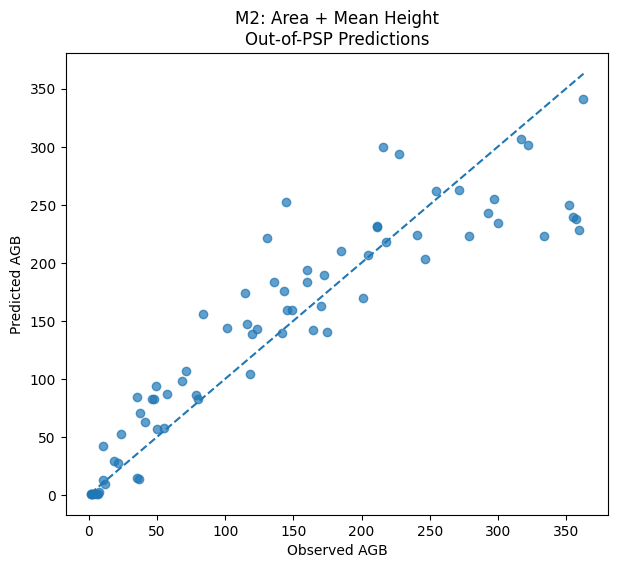

In [37]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m2_predictions["total_agb"],
    m2_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m2_predictions["total_agb"].min(),
    m2_predictions["prediction"].min()
)

max_val = max(
    m2_predictions["total_agb"].max(),
    m2_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title(
    "M2: Area + Mean Height\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

In [38]:
m2_predictions["residual"] = (
    m2_predictions["total_agb"]
    - m2_predictions["prediction"]
)

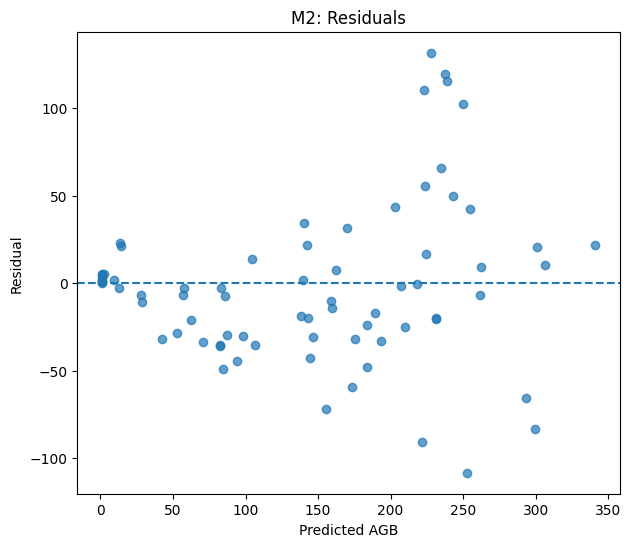

In [39]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m2_predictions["prediction"],
    m2_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")
plt.title("M2: Residuals")

plt.show()

In [40]:
# Fit M2 on all 2026 data for interpretation only

m2_full = LinearRegression()

m2_full.fit(
    model_df[
        [
            "canopy_area",
            "hmean"
        ]
    ],
    model_df["total_agb"]
)

print(
    "Intercept:",
    m2_full.intercept_
)

print(
    "Canopy area coefficient:",
    m2_full.coef_[0]
)

print(
    "Mean height coefficient:",
    m2_full.coef_[1]
)

Intercept: -139.14352181102794
Canopy area coefficient: 4.172852104870074
Mean height coefficient: 41.52791876719662


#### M3A: Polynomial Model

In [41]:
model_df.columns

Index(['psp', 'clump_id', 'total_agb', 'total_culms', 'canopy_volume_m3',
       'adjusted_volume', 'canopy_area', 'hmean', 'hmedian',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2'],
      dtype='str')

In [68]:
# ---------------------------------------
# M3: POLYNOMIAL VOLUME
# AGB ~ Volume + Volume²
# ---------------------------------------

m3_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    # -----------------------------
    # Training data
    # -----------------------------

    X_train = train[
        [ 'canopy_volume_m3'
         ]
    ]

    y_train = train[
        "total_agb"
    ]

    # -----------------------------
    # Test data
    # -----------------------------

    X_test = test[
        ['canopy_volume_m3'
         ]
    ]

    y_test = test[
        "total_agb"
    ]

    # -----------------------------
    # Create polynomial features
    # -----------------------------
    
    # 1. Target only 'canopy_volume_m3' for degree 2 (no bias column needed)
    # 2. Let 'remainder="passthrough"' keep all other features untouched
    poly_transformer = ColumnTransformer(
        transformers=[
            ('volume_poly', PolynomialFeatures(degree=2, include_bias=False), ['canopy_volume_m3'])
        ],
        remainder='passthrough' 
    )

    X_train_poly = poly_transformer.fit_transform(X_train)
    X_test_poly = poly_transformer.transform(X_test)

    # -----------------------------
    # Linear regression on
    # polynomial features
    # -----------------------------

    model = LinearRegression()

    model.fit(
        X_train_poly,
        y_train
    )

    # -----------------------------
    # Predict held-out PSP
    # -----------------------------

    y_pred = model.predict(
        X_test_poly
    )

    # -----------------------------
    # Store predictions
    # -----------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M3_polynomial_volume"

    m3_predictions.append(
        fold_results
    )


m3_predictions = pd.concat(
    m3_predictions,
    ignore_index=True
)

In [69]:
m3_metrics = calculate_metrics(
    m3_predictions["total_agb"],
    m3_predictions["prediction"]
)

print("M3: Polynomial Volume")
print("-" * 40)

for metric, value in m3_metrics.items():
    print(f"{metric}: {value:.4f}")

M3: Polynomial Volume
----------------------------------------
R2: 0.8399
MAE: 32.0877
RMSE: 44.2649
rRMSE_percent: 31.3741
MBE: 1.7107
Bias_percent: 31.9679
MAPE_percent: 70.2923


In [70]:
results_m0_m3 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        },
        {
            "Model": "M2 - Area + Mean Height",
            **m2_metrics
        },
        {
            "Model": "M3 - Polynomial Volume",
            **m3_metrics
        }
    ]
)

results_m0_m3

,Model,R2,MAE,RMSE,rRMSE_percent,MBE,Bias_percent,MAPE_percent
0,M0 - Null,-0.151776,100.555210,118.743332,84.162962,0.468115,-722.248670,758.704543
1,M1 - Linear Volume,0.837307,31.566344,44.628252,31.631636,1.371719,-19.620278,38.060972
2,M2 - Area + Mean Height,0.831050,32.245289,45.478296,32.234131,-2.273033,-12.207301,38.484142
3,M3 - Polynomial Volume,0.839945,32.087722,44.264915,31.374110,1.710703,31.967931,70.292257


In [71]:
print(
    "M3 vs M1"
)

print(
    "R² improvement:",
    m3_metrics["R2"] - m1_metrics["R2"]
)

print(
    "MAE improvement:",
    m1_metrics["MAE"] - m3_metrics["MAE"]
)

print(
    "RMSE improvement:",
    m1_metrics["RMSE"] - m3_metrics["RMSE"]
)

print(
    "rRMSE improvement:",
    m1_metrics["rRMSE_percent"] - m3_metrics["rRMSE_percent"]
)

M3 vs M1
R² improvement: 0.0026383159687247693
MAE improvement: -0.5213781407038169
RMSE improvement: 0.36333650870798095
rRMSE improvement: 0.25752584267871015


In [72]:
# Fit on the full dataset ONLY for examining coefficients

X = model_df[
    ["canopy_volume_m3"]
]

y = model_df[
    "total_agb"
]

poly_full = PolynomialFeatures(
    degree=1,
    include_bias=False
)

X_poly = poly_full.fit_transform(X)

m3_full = LinearRegression()

m3_full.fit(
    X_poly,
    y
)

print(
    "Features:",
    poly_full.get_feature_names_out(
        ["canopy_volume_m3"]
    )
)

print(
    "Coefficients:",
    m3_full.coef_
)

print(
    "Intercept:",
    m3_full.intercept_
)

Features: ['canopy_volume_m3']
Coefficients: [0.9797298]
Intercept: 2.3383306978105622


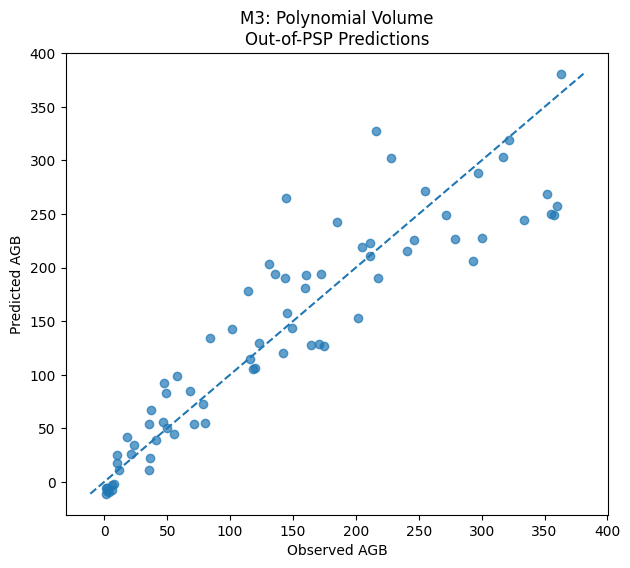

In [73]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m3_predictions["total_agb"],
    m3_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m3_predictions["total_agb"].min(),
    m3_predictions["prediction"].min()
)

max_val = max(
    m3_predictions["total_agb"].max(),
    m3_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")

plt.title(
    "M3: Polynomial Volume\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

In [74]:
m3_predictions["residual"] = (
    m3_predictions["total_agb"]
    - m3_predictions["prediction"]
)

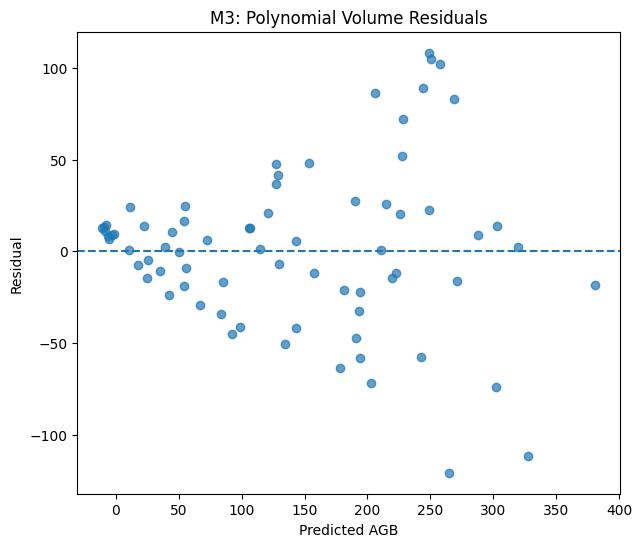

In [75]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m3_predictions["prediction"],
    m3_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")

plt.title(
    "M3: Polynomial Volume Residuals"
)

plt.show()

##### Per psp performance

In [76]:
m3_by_psp = []

for psp, group in m3_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m3_by_psp.append(metrics)


m3_by_psp = pd.DataFrame(
    m3_by_psp
)

m3_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.625209,25.144124,40.107770,55.663360
1,1a-APM-02,0.512547,29.587818,45.163280,54.728896
2,1a-APM-07,0.878496,20.704099,24.181007,22.722002
3,1a-APM-08,0.893570,25.512188,33.385836,28.269124
4,1a-APM-13,0.550161,53.499055,55.479768,50.049408
5,1a-GB-03,0.866172,26.155768,37.862993,16.253255
6,1a-GB-05,0.673967,53.500162,63.548770,28.344408


In [83]:
model_df[model_df['psp'] == '1a-APM-02'][['clump_id', 'canopy_volume_m3', 'total_agb', 'hmean']]

,clump_id,canopy_volume_m3,total_agb,hmean
33,CLUMP #2,3.27,2.31,2.73
37,CLUMP #4,67.53,78.65,3.74
39,CLUMP #5,3.83,1.31,2.94
41,CLUMP #6,62.36,37.37,3.48
43,CLUMP #7,35.89,23.73,3.68
45,CLUMP #8,39.13,41.22,3.93
47,CLUMP #9,179.01,135.50,4.45
49,CLUMP #10,117.73,123.01,4.56
51,CLUMP #11,96.00,118.07,3.74
53,CLUMP #13,188.14,130.87,5.60


#### M4: Normal Logarithm Power model

In [51]:
print("Minimum AGB:", model_df["total_agb"].min())
print("Minimum volume:", model_df["canopy_volume_m3"].min())

Minimum AGB: 1.31
Minimum volume: 1.87


In [52]:
from sklearn.preprocessing import FunctionTransformer

# ---------------------------------------
# M4: POWER MODEL
# log(AGB) ~ log(Features)
# ---------------------------------------

m4_predictions = []

# List all 5 features to maintain consistency with M3
features_to_use = [
   'canopy_volume_m3', 'hmean'
]

# Custom function to safely handle any unexpected negative sensor artifacts
def safe_log1p(X):
    return np.log1p(np.clip(X, a_min=0, a_max=None))

for train_idx, test_idx in gkf.split(
    m3_predictions_culms,
    groups=groups
):
    train = m3_predictions_culms.iloc[train_idx]
    test = m3_predictions_culms.iloc[test_idx]

    # -----------------------------
    # Data splitting
    # -----------------------------
    X_train = train[features_to_use]
    X_test = test[features_to_use]
    
    # Target log transformation (safe from 0 values)
    y_train = np.log1p(train["total_agb"])
    
    # -----------------------------
    # Log transform features
    # -----------------------------
    log_transformer = ColumnTransformer(
        transformers=[
            ('log_transform', FunctionTransformer(safe_log1p), ['canopy_volume_m3'])
        ],
        remainder='passthrough'
    )

    # Use .values to ensure smooth evaluation with the custom function
    X_train_log = log_transformer.fit_transform(X_train)
    X_test_log = log_transformer.transform(X_test)

    # -----------------------------
    # Fit log-log linear model
    # -----------------------------
    model = LinearRegression()
    model.fit(
        X_train_log,
        y_train
    )

    # -----------------------------
    # Predict and transform back
    # -----------------------------
    log_pred = model.predict(X_test_log)
    
    # Convert predictions back to original AGB scale safely
    y_pred = np.expm1(log_pred)

    # -----------------------------
    # Store predictions
    # -----------------------------
    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M4_power_volume_mean_height"

    m4_predictions.append(fold_results)

m4_predictions = pd.concat(
    m4_predictions,
    ignore_index=True
)

In [53]:
m4_metrics = calculate_metrics(
    m4_predictions["total_agb"],
    m4_predictions["prediction"]
)

print("M4: Power Volume")
print("-" * 40)

for metric, value in m4_metrics.items():
    print(f"{metric}: {value:.4f}")

M4: Power Volume
----------------------------------------
R2: 0.8521
MAE: 29.3739
RMSE: 42.5521
rRMSE_percent: 30.1601
MBE: 0.7936
Bias_percent: -7.4561
MAPE_percent: 28.8132


In [54]:
results_m0_m4 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        },
        {
            "Model": "M2 - Area + Mean Height",
            **m2_metrics
        },
        {
            "Model": "M3 - Polynomial Volume",
            **m3_metrics
        },
        {
            "Model": "M4 - Power Volume",
            **m4_metrics
        }
    ]
)

results_m0_m4

,Model,R2,MAE,RMSE,rRMSE_percent,MBE,Bias_percent,MAPE_percent
0,M0 - Null,-0.151776,100.555210,118.743332,84.162962,0.468115,-722.248670,758.704543
1,M1 - Linear Volume,0.837307,31.566344,44.628252,31.631636,1.371719,-19.620278,38.060972
2,M2 - Area + Mean Height,0.831050,32.245289,45.478296,32.234131,-2.273033,-12.207301,38.484142
3,M3 - Polynomial Volume,0.860134,29.435915,41.379075,29.328683,1.201632,39.730483,90.677365
4,M4 - Power Volume,0.852092,29.373927,42.552056,30.160068,0.793637,-7.456142,28.813163


In [55]:
# ---------------------------------------
# Full-data power model
# Interpretation only
# ---------------------------------------

X_full = np.log(
    model_df[["canopy_volume_m3"]]
)

y_full = np.log(
    model_df["total_agb"]
)

power_full = LinearRegression()

power_full.fit(
    X_full,
    y_full
)

alpha = power_full.intercept_
b = power_full.coef_[0]

a = np.exp(alpha)

print("a =", a)
print("b =", b)

print(
    f"AGB = {a:.4f} × Volume^{b:.4f}"
)

a = 0.7159356693878456
b = 1.0565729842897131
AGB = 0.7159 × Volume^1.0566


### Weighted Power Model

In [56]:
# ---------------------------------------
# MW4: WEIGHTED POWER / LOG-LOG MODEL
# ---------------------------------------

weighted_power_predictions = []

features_to_use = [
    "canopy_volume_m3", 'hmean'
]

target_col = "total_agb"

# Feature columns that will be log-transformed
log_features = features_to_use

# Column used to calculate the observation weights.
# This is the closest equivalent to the paper's log(D)-based weighting.
weight_feature = "canopy_volume_m3"

In [57]:
def safe_log(X, columns=None):
    """
    Apply natural logarithm while checking for invalid values.

    Parameters
    ----------
    X : pandas DataFrame or numpy array
        Input values.
    columns : list, optional
        Column names used for clearer error reporting.

    Returns
    -------
    numpy.ndarray
        Log-transformed values.
    """

    X_array = np.asarray(X, dtype=float)

    if np.any(~np.isfinite(X_array)):
        raise ValueError("Input contains NaN or infinite values.")

    if np.any(X_array <= 0):
        invalid_count = np.sum(X_array <= 0)

        raise ValueError(
            f"Log transformation encountered {invalid_count} "
            "zero or negative values."
        )

    return np.log(X_array)

In [58]:
check_cols = features_to_use + [target_col]

print(
    m3_predictions_culms[check_cols]
    .describe()
    .T
)

print("\nNon-positive values:")
print(
    (m3_predictions_culms[check_cols] <= 0)
    .sum()
)

                  count        mean         std   min    25%     50%     75%  \
canopy_volume_m3   73.0  141.619726  105.194847  1.87  51.51  123.58  223.51   
hmean              73.0    4.351781    1.146903  1.49   3.51    4.50    5.08   
total_agb          73.0  141.087397  111.409054  1.31  41.22  130.87  215.70   

                     max  
canopy_volume_m3  431.76  
hmean               6.80  
total_agb         362.77  

Non-positive values:
canopy_volume_m3    0
hmean               0
total_agb           0
dtype: int64


In [59]:
# ---------------------------------------
# GroupKFold by PSP
# ---------------------------------------

gkf = GroupKFold(n_splits=5)

for fold_number, (train_idx, test_idx) in enumerate(
    gkf.split(
        m3_predictions_culms,
        groups=groups
    ),
    start=1
):

    train = m3_predictions_culms.iloc[train_idx].copy()
    test = m3_predictions_culms.iloc[test_idx].copy()

    # ---------------------------------------
    # Data splitting
    # ---------------------------------------

    X_train = train[features_to_use].copy()
    X_test = test[features_to_use].copy()

    y_train = train[target_col].to_numpy(dtype=float)
    y_test = test[target_col].to_numpy(dtype=float)

    # ---------------------------------------
    # Log-transform predictors and target
    # ---------------------------------------

    X_train_log = safe_log(
        X_train,
        columns=log_features
    )

    X_test_log = safe_log(
        X_test,
        columns=log_features
    )

    y_train_log = safe_log(y_train)

    # ---------------------------------------
    # Calculate weights
    # ---------------------------------------
    # Paper:
    # weights = 1 / log(D)^2
    #
    # Here:
    # weights = 1 / log(canopy_volume_m3)^2
    #
    # Weights are calculated from training data only.
    # ---------------------------------------

    log_weight_variable = np.log(
        train[weight_feature].to_numpy(dtype=float)
    )

    if np.any(~np.isfinite(log_weight_variable)):
        raise ValueError(
            f"Invalid log values encountered in fold {fold_number}."
        )

    if np.any(np.isclose(log_weight_variable, 0)):
        raise ValueError(
            f"One or more weights are unstable in fold {fold_number}: "
            f"log({weight_feature}) is close to zero."
        )

    sample_weights = 1 / (log_weight_variable ** 2)

    # ---------------------------------------
    # Optional weight diagnostics
    # ---------------------------------------

    print(f"\nFold {fold_number} weight diagnostics")
    print("-" * 40)
    print(f"Minimum weight: {sample_weights.min():.6f}")
    print(f"Maximum weight: {sample_weights.max():.6f}")
    print(f"Median weight:  {np.median(sample_weights):.6f}")

    # ---------------------------------------
    # Fit weighted log-log linear model
    # ---------------------------------------

    model = LinearRegression()

    model.fit(
        X_train_log,
        y_train_log,
        sample_weight=sample_weights
    )

    # ---------------------------------------
    # Training residuals on log scale
    # ---------------------------------------

    train_log_pred = model.predict(X_train_log)
    train_log_residuals = y_train_log - train_log_pred

    n_train = len(y_train_log)
    n_parameters = X_train_log.shape[1] + 1  # predictors + intercept

    residual_degrees_of_freedom = n_train - n_parameters

    if residual_degrees_of_freedom <= 0:
        raise ValueError(
            f"Insufficient residual degrees of freedom in fold "
            f"{fold_number}."
        )

    # Weighted residual variance.
    #
    # This is the closest equivalent to the residual scale used
    # by weighted lm() in R.
    weighted_sse = np.sum(
        sample_weights * train_log_residuals ** 2
    )

    sigma_squared = (
        weighted_sse / residual_degrees_of_freedom
    )

    sigma = np.sqrt(sigma_squared)

    # ---------------------------------------
    # Lognormal retransformation correction
    # ---------------------------------------
    #
    # CF = exp(RSE^2 / 2)
    # ---------------------------------------

    correction_factor = np.exp(sigma_squared / 2)

    # ---------------------------------------
    # Predict on test data
    # ---------------------------------------

    test_log_pred = model.predict(X_test_log)

    # Standard log-log back-transformation:
    # exp(predicted log AGB)
    #
    # Bias-corrected:
    # exp(predicted log AGB) * CF
    # ---------------------------------------

    y_pred = np.exp(test_log_pred) * correction_factor

    # ---------------------------------------
    # Store predictions
    # ---------------------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            target_col
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["fold"] = fold_number
    fold_results["correction_factor"] = correction_factor
    fold_results["sigma_squared_log"] = sigma_squared
    fold_results["model"] = "MW4_weighted_power"

    weighted_power_predictions.append(fold_results)


Fold 1 weight diagnostics
----------------------------------------
Minimum weight: 0.027160
Maximum weight: 2.552330
Median weight:  0.043318

Fold 2 weight diagnostics
----------------------------------------
Minimum weight: 0.029403
Maximum weight: 2.552330
Median weight:  0.041072

Fold 3 weight diagnostics
----------------------------------------
Minimum weight: 0.027160
Maximum weight: 2.552330
Median weight:  0.043454

Fold 4 weight diagnostics
----------------------------------------
Minimum weight: 0.027160
Maximum weight: 2.552330
Median weight:  0.039826

Fold 5 weight diagnostics
----------------------------------------
Minimum weight: 0.027160
Maximum weight: 0.712389
Median weight:  0.043318


In [60]:
weighted_power_predictions = pd.concat(
    weighted_power_predictions,
    ignore_index=True
)

weighted_power_metrics = calculate_metrics(
    weighted_power_predictions[target_col],
    weighted_power_predictions["prediction"]
)

print("\nMW4: Weighted Power Model")
print("-" * 40)

for metric, value in weighted_power_metrics.items():
    print(f"{metric}: {value:.4f}")


MW4: Weighted Power Model
----------------------------------------
R2: 0.8322
MAE: 32.7245
RMSE: 45.3242
rRMSE_percent: 32.1249
MBE: 1.8827
Bias_percent: -8.8005
MAPE_percent: 32.8182


##### Site specific

In [62]:
m4_by_psp = []

for psp, group in m4_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m4_by_psp.append(metrics)


m4_by_psp = pd.DataFrame(
    m4_by_psp
)

m4_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.735013,18.592582,33.724567,46.804464
1,1a-APM-02,0.385748,31.940798,50.698173,61.436084
2,1a-APM-07,0.843070,20.995524,27.480968,25.822853
3,1a-APM-08,0.919283,19.089143,29.074596,24.618625
4,1a-APM-13,0.893120,23.890845,27.042949,24.395985
5,1a-GB-03,0.691318,45.072246,57.503764,24.684350
6,1a-GB-05,0.804488,40.375080,49.211147,21.949454


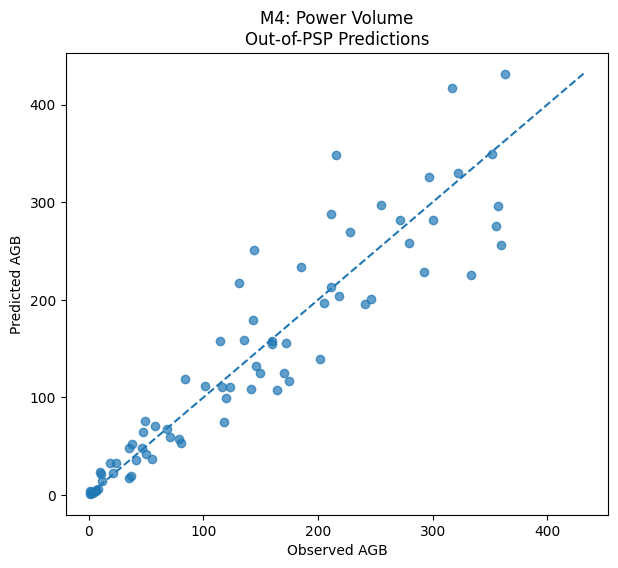

In [63]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m4_predictions["total_agb"],
    m4_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m4_predictions["total_agb"].min(),
    m4_predictions["prediction"].min()
)

max_val = max(
    m4_predictions["total_agb"].max(),
    m4_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title(
    "M4: Power Volume\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

In [64]:
m4_predictions["residual"] = (
    m4_predictions["total_agb"]
    - m4_predictions["prediction"]
)

##### Biomass across levels

In [65]:
m4_predictions["biomass_bin"] = pd.qcut(
    m4_predictions["total_agb"],
    q=4,
    duplicates="drop"
)

m4_bias_by_bin = (
    m4_predictions
    .groupby(
        "biomass_bin",
        observed=True
    )
    .agg(
        observed_mean=("total_agb", "mean"),
        predicted_mean=("prediction", "mean"),
        mean_residual=("residual", "mean"),
        MAE=(
            "residual",
            lambda x: np.mean(np.abs(x))
        ),
        n=("residual", "size")
    )
)

m4_bias_by_bin

,observed_mean,predicted_mean,mean_residual,MAE,n
biomass_bin,,,,,
"(1.3090000000000002, 41.22]",16.390526,18.422268,-2.031742,6.771155,19
"(41.22, 130.87]",83.911667,87.504462,-3.592795,22.296862,18
"(130.87, 215.7]",171.633889,177.350601,-5.716712,41.675603,18
"(215.7, 362.77]",299.341111,284.668348,14.672763,48.007800,18


#### M5: Random Forest

In [66]:
# ---------------------------------------
# M5: tree based
# ---------------------------------------

m5_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    # -----------------------------
    # Training data
    # -----------------------------

    X_train = train[
        ['canopy_volume_m3', 'hmean', 'breast_height_diameter']
    ]

    y_train = train[
        "total_agb"
    ]

    # -----------------------------
    # Test data
    # -----------------------------

    X_test = test[
        ['canopy_volume_m3', 'hmean', 'breast_height_diameter']
    ]

    y_test = test[
        "total_agb"
    ]


    # -----------------------------
    # Random forest regression
    # -----------------------------

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    # -----------------------------
    # Predict held-out PSP
    # -----------------------------

    y_pred = model.predict(
        X_test
    )

    # -----------------------------
    # Store predictions
    # -----------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M5_random_forest"

    m5_predictions.append(
        fold_results
    )


m5_predictions = pd.concat(
    m5_predictions,
    ignore_index=True
)

In [67]:
m5_metrics = calculate_metrics(
    m5_predictions["total_agb"],
    m5_predictions["prediction"]
)

print("M5: Random Forest")
print("-" * 40)

for metric, value in m5_metrics.items():
    print(f"{metric}: {value:.4f}")

M5: Random Forest
----------------------------------------
R2: 0.8041
MAE: 33.3864
RMSE: 48.9745
rRMSE_percent: 34.7122
MBE: 2.6672
Bias_percent: -40.2356
MAPE_percent: 56.7817
